In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from math import radians, cos, sin, asin, sqrt

df = pd.read_csv("df_assignment.csv.gz", )


focus_crime = [
    "larceny theft",
    "motor vehicle theft",
    "robbery",
    "assault",
    "drug offense",
    "weapons offense",
    "vandalism",
    "suicide",
]


* Step 1: Divide San Francisco into a grid of approximately 
 cells using latitude and longitude. It is fine to ignore that the Earth isn't flat — the approximation is good enough for this purpose.

In [43]:
# theft data
theft_data = df[df["category"] == "larceny theft"]

lon = pd.to_numeric(theft_data["longitude"], errors="coerce")
lat = pd.to_numeric(theft_data["latitude"], errors="coerce")

mask = (
    (lon > -123.0) & (lon < -122.) &
    (lat > 37.0)   & (lat < 38.18)
)

lon = lon[mask].to_numpy()
lat = lat[mask].to_numpy()


def haversine(lon1, lat1, lon2, lat2):
    """
    Calculate the great circle distance between two points 
    on the earth (specified in decimal degrees)
    """
    # convert decimal degrees to radians 
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])

    # haversine formula 
    dlon = lon2 - lon1 
    dlat = lat2 - lat1 
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a)) 
    r = 6371 # Radius of earth in kilometers. Use 3956 for miles
    return c * r

# after some testing we found that 0.2 km is a good bin size for our grid
bin_size_km = 0.2  

lon_min, lon_max = lon.min(), lon.max()
lat_min, lat_max = lat.min(), lat.max()

height_km = haversine(lon_min, lat_min, lon_min, lat_max)

width_km_bottom = haversine(lon_min, lat_min, lon_max, lat_min)
width_km_top    = haversine(lon_min, lat_max, lon_max, lat_max)
width_km = 0.5 * (width_km_bottom + width_km_top)

n_lat_bins = int(np.ceil(height_km / bin_size_km))
n_lon_bins = int(np.ceil(width_km  / bin_size_km))

print( "amount_lon_bins:", n_lon_bins, "amount_lat_bins:", n_lat_bins)

total_cells = n_lon_bins * n_lat_bins
print("total cells:", total_cells)

amount_lon_bins: 66 amount_lat_bins: 68
total cells: 4488


* Step 2: Count the number of incidents of your chosen crime in each grid cell (use all years of data).

* Step 3: Tally the distribution. Count how many cells have exactly 
 incidents — call this 
 — for 
 up to the maximum.


In [44]:
counts, lon_edges, lat_edges = np.histogram2d(
    lon, lat,
    bins=[n_lon_bins, n_lat_bins],
    range=[[lon_min, lon_max], [lat_min, lat_max]]
)

cell_counts = counts.flatten().astype(int)

# counting how many cells have k counts
nk = np.bincount(cell_counts)
k_vals = np.arange(len(nk))

print("Amount of empty cells:", nk[0])

Amount of empty cells: 1894


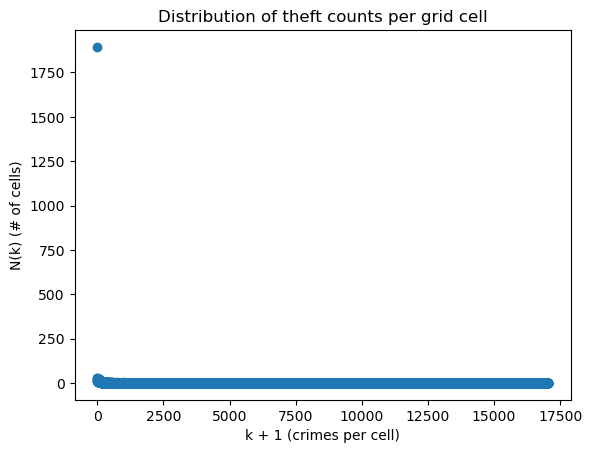

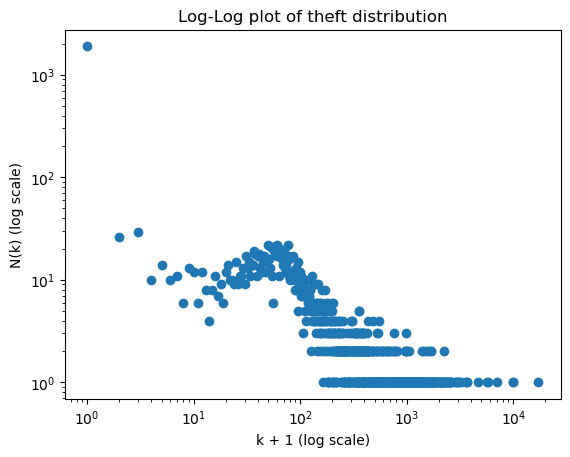

In [45]:
plt.figure()
plt.plot(k_vals + 1, nk, marker="o", linestyle="none")
plt.xlabel("k + 1 (crimes per cell)")
plt.ylabel("N(k) (# of cells)")
plt.title("Distribution of theft counts per grid cell")
plt.show()

plt.figure()
plt.loglog(k_vals + 1, nk, marker="o", linestyle="none")
plt.xlabel("k + 1 (log scale)")
plt.ylabel("N(k) (log scale)")
plt.title("Log-Log plot of theft distribution")
plt.show()

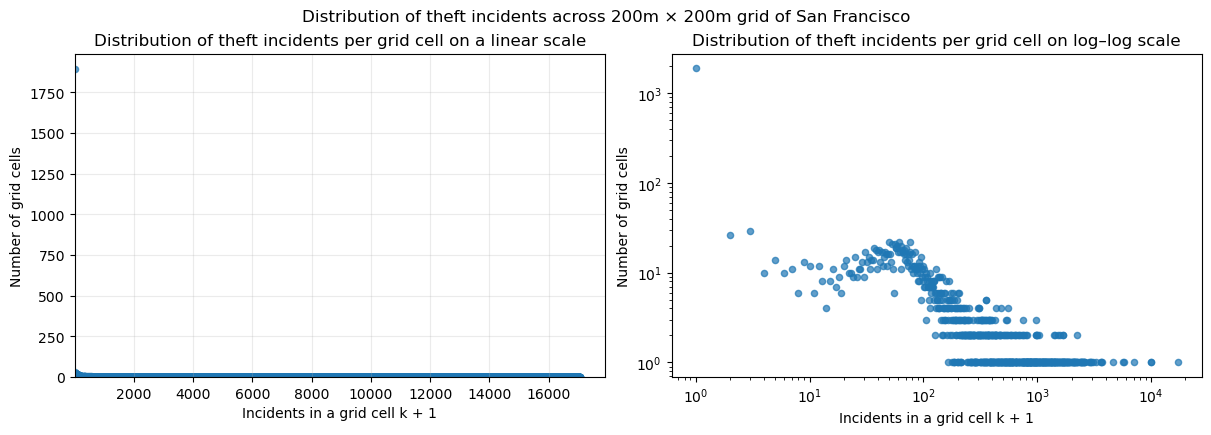

In [46]:
x = k_vals + 1
y = nk

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

# Linear plot
ax = axes[0]
ax.scatter(x, y, s=20, alpha=0.7)
ax.set_title("Distribution of theft incidents per grid cell on a linear scale")
ax.set_xlabel("Incidents in a grid cell k + 1")
ax.set_ylabel("Number of grid cells")
ax.grid(True, alpha=0.25)


ax.set_ylim(bottom=0)
ax.set_xlim(left=1)


# Log-log plot
ax = axes[1]

mask = y > 0
ax.scatter(x[mask], y[mask], s=20, alpha=0.7)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_title("Distribution of theft incidents per grid cell on log–log scale")
ax.set_xlabel("Incidents in a grid cell k + 1")
ax.set_ylabel("Number of grid cells")


fig.suptitle(
    "Distribution of theft incidents across 200m × 200m grid of San Francisco",
    y=1.05
)

plt.show()

The linear plot clearly show why sometimes you need a log-log plot to reveal trends within data, as we can cleary see that more than half of the cells have 0 incidents of theft and the rest are spread so thin that it is not visibly possible to see if there is any numerical difference between the values.

When we examine the log–log plot, we do not see a single straight line across the full range, which we would expect if the distribution followed a perfect power law. Instead, we observe a very large number of cells with only a few incidents and a small number of cells with very high incident counts, while relatively few cells fall in the mid-range. This indicates a heavy-tailed distribution, where crime is highly concentrated in a limited number of hotspots.

This pattern makes sense in a real-world context. Most areas of San Francisco are residential or low-activity zones where theft incidents are rare, while a small number of locations such as downtown areas, commercial districts, and transit hubs attract large crowds and therefore present more opportunities for theft. As a result, crime is not evenly distributed across space but is instead clustered in specific high-activity areas. This helps explain why we see many low-count cells, a few extreme hotspots, and fewer cells with moderate levels of crime. We have also plotted a heatmat plot to investigate this a bit further.

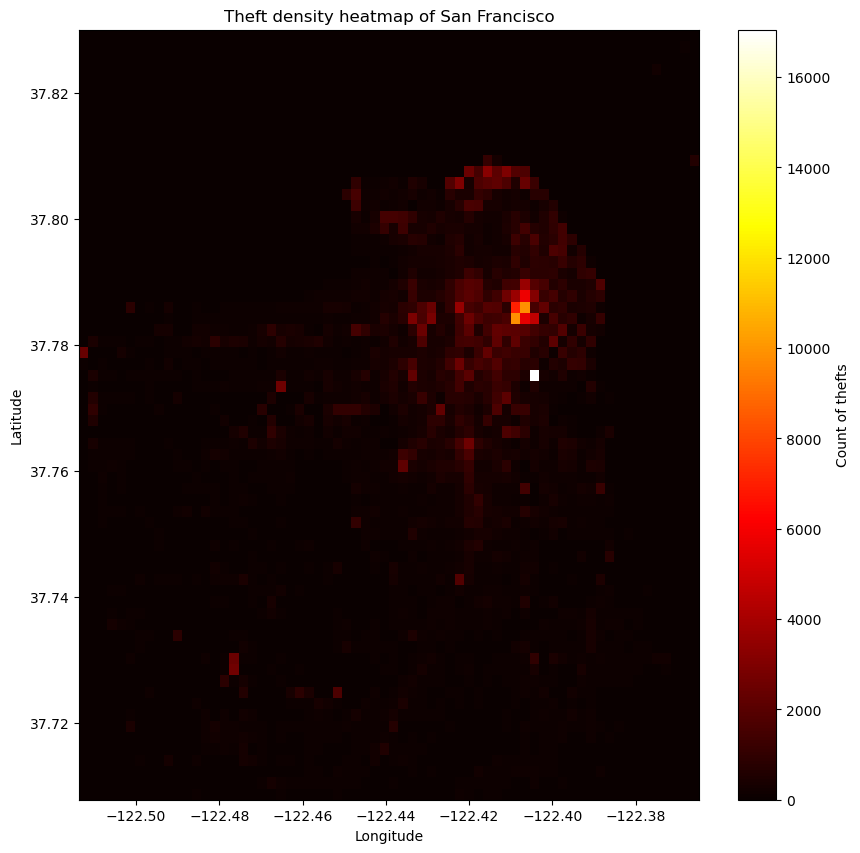

In [51]:
plt.figure(figsize=(10, 10))
plt.imshow(
    counts.T,
    cmap="hot",
    origin="lower",
    extent=[lon_min, lon_max, lat_min, lat_max],
    aspect="auto"
)
plt.colorbar(label="Count of thefts")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Theft density heatmap of San Francisco")
plt.show()

The above plot clearly show the same thing as we could see in the above log-log plot that a lot of the San Francisco map is dark and has little to no incidents of theft, while a few specific cells in the downtown area glow a lot. Another discovery we found from this plot is that it is very likely that since we have put a grid on San Francisco, then a lot of the cells with 0 incidents actually come from the sea around the peninsula, which gives a wrong over representation of 0 crime cells in the statistic. 